Testing out pynaple and dandi env on this dataset: https://dandiarchive.org/dandiset/001695/0.260319.2023

In [1]:
import sys
# install into THIS kernel's interpreter (pynapple_dandi_env), not system python
!{sys.executable} -m pip install hmmlearn

  Using cached hmmlearn-0.3.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (3.0 kB)
Using cached hmmlearn-0.3.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (165 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 73.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [hmmlearn]2/3 [hmmlearn]arn]


In [3]:
import sys
# sys.executable = the exact python running THIS kernel (your pynapple_dandi_env)
# using "-m pip" guarantees the matching pip, not whatever `pip` resolves to on PATH
!{sys.executable} -m pip install matplotlib
print("\nInstalled into:", sys.executable)


Installed into: /storage/conda_envs/pynapple_dandi_env/bin/python


In [4]:
from pathlib import Path
from dandi.dandiapi import DandiAPIClient
import pynapple as nap

# ---- config ----
DANDISET_ID = "001695"
VERSION_ID  = "0.260319.2023"
SUBJECT     = "sub-M01/"                                  # which subject to scan
DOWNLOAD_DIR = Path("../../storage/dandi_downloads").resolve()
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)          # storage folder (create if missing)

# ---- discover sessions, pick smallest to keep it quick ----
with DandiAPIClient() as client:
    dandiset = client.get_dandiset(DANDISET_ID, VERSION_ID)
    sessions = [(a.path, a.size)
                for a in dandiset.get_assets_with_path_prefix(SUBJECT, order="path")]
    # behavior+ecephys sessions are the ones with position data; prefer those
    behavior = [s for s in sessions if "behavior" in s[0]]
    pool = behavior or sessions                          # fall back to any if none flagged
    target_path = min(pool, key=lambda t: t[1])[0]       # smallest in the pool
    print("Picked:", target_path)

    # ---- download into storage (make nested sub-XX/ parent first) ----
    asset = dandiset.get_asset_by_path(target_path)
    asset_out = DOWNLOAD_DIR / target_path
    asset_out.parent.mkdir(parents=True, exist_ok=True)  # download() won't create dirs
    if not asset_out.exists():                           # skip re-download if already local
        asset.download(asset_out)
    print("Local file:", asset_out)

# ---- load in pynapple ----
data = nap.load_file(str(asset_out))
print("\nObjects in this NWB file:")
print(data)                                              # look here for position/behavior keys

# ---- find spatial-navigation data ----
# pynapple exposes NWB objects by key; spatial data is usually a TsdFrame of x/y
# common keys across datasets: "position", "SpatialSeries", "head_position", etc.
spatial_keys = [k for k in data.keys()
                if any(w in k.lower() for w in ["position", "spatial", "pos", "head"])]
print("\nCandidate spatial keys:", spatial_keys)

if spatial_keys:
    pos = data[spatial_keys[0]]                          # TsdFrame: columns are x/y (/z)
    print(f"\nUsing '{spatial_keys[0]}':")
    print(pos)
    print("Columns:", list(getattr(pos, "columns", [])))
    print("Time span (s):", pos.index[-1] - pos.index[0])
else:
    print("\nNo obvious spatial key — print(data) above to see actual object names.")

A newer version (0.79.0) of dandi/dandi-cli is available. You are using 0.78.0


Picked: sub-M01/sub-M01_ses-20240313T100000_behavior+ecephys.nwb
Local file: /storage/dandi_downloads/sub-M01/sub-M01_ses-20240313T100000_behavior+ecephys.nwb


/storage/conda_envs/pynapple_dandi_env/lib/python3.11/site-packages/numcodecs/__init__.py:106: DeprecationWarning: crc32c usage is deprecated since numcodecs v0.16.4. It is recommended to install google_crc32c instead.
  from numcodecs.checksum32 import CRC32, Adler32, JenkinsLookup3



Objects in this NWB file:
sub-M01_ses-20240313T100000_behavior+ecephys
┍━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━┑
│ Keys                        │ Type        │
┝━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━┥
│ units                       │ TsGroup     │
│ SleepStates                 │ IntervalSet │
│ Best_Ripple_channel_LFP_CA1 │ TsdFrame    │
│ Speed                       │ Tsd         │
│ Position                    │ TsdFrame    │
┕━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━┙

Candidate spatial keys: ['Position']

Using 'Position':
Time (s)                  x        y
------------------  -------  -------
4892.8469000000005  10.2028  15.5703
4892.8872854166675  10.204   15.5773
4892.927670833334   10.204   15.5891
4892.968056250001   10.204   15.6471
4893.008441666667   10.2028  15.6471
4893.048827083334   10.1692  15.6471
4893.0892125        10.1194  15.6471
...
6520.931772357723   43.0673  16.3426
6520.972332520325   43.477   16.3957
6521.012892682927   44.0497  16.4489
6521.0534

In [5]:
import pynapple as nap
from pathlib import Path

asset_out = Path("../../storage/dandi_downloads/sub-M01/"
                 "sub-M01_ses-20240313T100000_behavior+ecephys.nwb").resolve()
data = nap.load_file(str(asset_out))

# ---- pynapple's view: top-level objects and their types ----
print("=" * 60)
print("PYNAPPLE OBJECTS")
print("=" * 60)
print(data)

# ---- units TsGroup: metadata columns + shape ----
units = data["units"]
print("\n" + "=" * 60)
print("UNITS (TsGroup)")
print("=" * 60)
print("n_units:", len(units))
print("metadata_columns:", list(units.metadata_columns))
print("\nfull metadata table:")
print(units.metadata)                     # every per-unit column, all rows

# ---- each non-units object: type, shape, columns, time span ----
print("\n" + "=" * 60)
print("OTHER OBJECTS")
print("=" * 60)
for key in data.keys():
    if key == "units":
        continue
    obj = data[key]
    line = f"{key:32s} {type(obj).__name__}"
    if hasattr(obj, "columns"):
        line += f"  cols={list(obj.columns)}"
    if hasattr(obj, "shape"):
        line += f"  shape={obj.shape}"
    if hasattr(obj, "index") and len(obj) > 0:
        line += f"  t=[{obj.index[0]:.1f}, {obj.index[-1]:.1f}]s"
    elif hasattr(obj, "start"):            # IntervalSet
        line += f"  n_intervals={len(obj)}"
    print(line)

# ---- raw NWB hierarchy (the underlying file, everything pynapple didn't surface) ----
print("\n" + "=" * 60)
print("RAW NWB TREE")
print("=" * 60)
try:
    import pynwb, h5py
    with pynwb.NWBHDF5IO(str(asset_out), mode="r") as io:
        nwb = io.read()
        print(nwb)                          # full NWB object: acquisition, processing, intervals, etc.
except Exception as e:
    print("Could not open raw NWB:", e)

PYNAPPLE OBJECTS
sub-M01_ses-20240313T100000_behavior+ecephys
┍━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━┑
│ Keys                        │ Type        │
┝━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━┥
│ units                       │ TsGroup     │
│ SleepStates                 │ IntervalSet │
│ Best_Ripple_channel_LFP_CA1 │ TsdFrame    │
│ Speed                       │ Tsd         │
│ Position                    │ TsdFrame    │
┕━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━┙

UNITS (TsGroup)
n_units: 240
metadata_columns: ['rate', 'cell_type', 'cell_area', 'firing_rate', 'ab_ratio', 'burstIndex_Mizuseki2012', 'cv2', 'maxWaveformCh', 'troughToPeak', 'acg_tau_decay', 'acg_tau_rise', 'thetaModulationIndex', 'x_position_probe', 'y_position_probe']

full metadata table:
         rate           cell_type cell_area  firing_rate  ab_ratio  \
1    9.909396  Narrow Interneuron       CA3     9.909626 -0.535097   
2    7.957887  Narrow Interneuron       CA3     7.959234 -0.172564   
3    0.815371     

/storage/conda_envs/pynapple_dandi_env/lib/python3.11/site-packages/pynapple/io/interface_nwb.py:133: UserWarning: end is not sorted. Cannot add metadata to unsorted end times. Sorting it and dropping metadata.
  data = nap.IntervalSet(df)
/storage/conda_envs/pynapple_dandi_env/lib/python3.11/site-packages/pynapple/io/interface_nwb.py:133: UserWarning: Some starts precede the previous end. Joining them!
  data = nap.IntervalSet(df)
/storage/conda_envs/pynapple_dandi_env/lib/python3.11/site-packages/pynapple/io/interface_nwb.py:133: UserWarning: epochs have changed, dropping metadata.
  data = nap.IntervalSet(df)


Best_Ripple_channel_LFP_CA1      TsdFrame  cols=[0]  shape=(13985972, 1)  t=[0.0, 11188.8]s
Speed                            Tsd  shape=(40708,)  t=[4892.8, 6521.2]s
Position                         TsdFrame  cols=['x', 'y']  shape=(40708, 2)  t=[4892.8, 6521.2]s

RAW NWB TREE
root pynwb.file.NWBFile at 0x140526756492880
Fields:
  devices: {
    Neuropixels 2.0 <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    ElectrodeGroup1 <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'pynwb.ecephys.ElectrodesTable'>
  experimenter: ['Mihály Vöröslakos']
  file_create_date: [datetime.datetime(2026, 1, 13, 16, 16, 18, 804970, tzinfo=tzoffset(None, -18000))]
  identifier: name
  institution: NYU
  intervals: {
    SleepStates <class 'pynwb.epoch.TimeIntervals'>
  }
  lab: Buzsáki Lab
  processing: {
    behavior <class 'pynwb.base.ProcessingModule'>,
    ecephys <class 'pynwb.base.ProcessingModule'>
  }
  session_description: Novel Maze Session with Pre and Post 

Metadata columns on units: ['rate', 'cell_type', 'cell_area', 'firing_rate', 'ab_ratio', 'burstIndex_Mizuseki2012', 'cv2', 'maxWaveformCh', 'troughToPeak', 'acg_tau_decay', 'acg_tau_rise', 'thetaModulationIndex', 'x_position_probe', 'y_position_probe']

Counts (region x cell_type, with Total):
type  Total  Narrow Interneuron  Pyramidal Cell  Wide Interneuron
area                                                             
CA1     103                  15              85                 3
CA3      83                  55              27                 1
RSC      54                  23              15                16


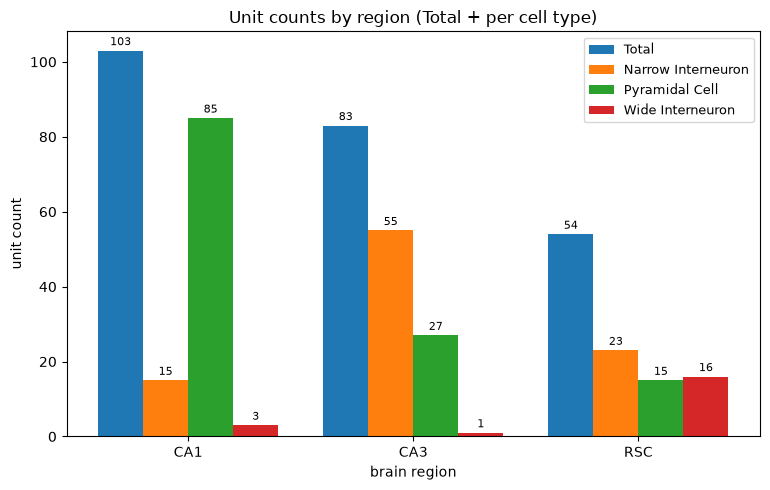

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# per-unit metadata available on the TsGroup (summary scores + labels, not spikes)
print("Metadata columns on units:", list(units.metadata_columns))

region_col = "cell_area"   # region label; 'cell_type' = narrow/wide interneuron etc.

regions = np.asarray(units.get_info(region_col))
cell_types = np.asarray(units.get_info("cell_type"))

# build a region x cell_type count table, then add a "Total" column
tab = pd.crosstab(pd.Series(regions, name="area"),
                  pd.Series(cell_types, name="type"))
tab.insert(0, "Total", tab.sum(axis=1))   # Total first, then each cell type
print("\nCounts (region x cell_type, with Total):")
print(tab)

# ---- grouped bar plot: regions on X, (Total + each cell_type) bars per region ----
areas = tab.index.tolist()          # X groups
cols = tab.columns.tolist()         # bars within each group: ['Total', type1, type2, ...]
n_bars = len(cols)
x = np.arange(len(areas))
width = 0.8 / n_bars                 # fit all bars within each region slot

fig, ax = plt.subplots(figsize=(1.6 * len(areas) + 3, 5))
cmap = plt.get_cmap("tab10")

for i, col in enumerate(cols):
    offsets = x + (i - (n_bars - 1) / 2) * width   # center the group on the tick
    bars = ax.bar(offsets, tab[col].values, width,
                  label=col, color=cmap(i))
    ax.bar_label(bars, padding=2, fontsize=8)      # count above each bar

ax.set_xticks(x); ax.set_xticklabels(areas)
ax.set(xlabel="brain region", ylabel="unit count",
       title="Unit counts by region (Total + per cell type)")
ax.legend(title="", fontsize=9)
plt.tight_layout(); plt.show()

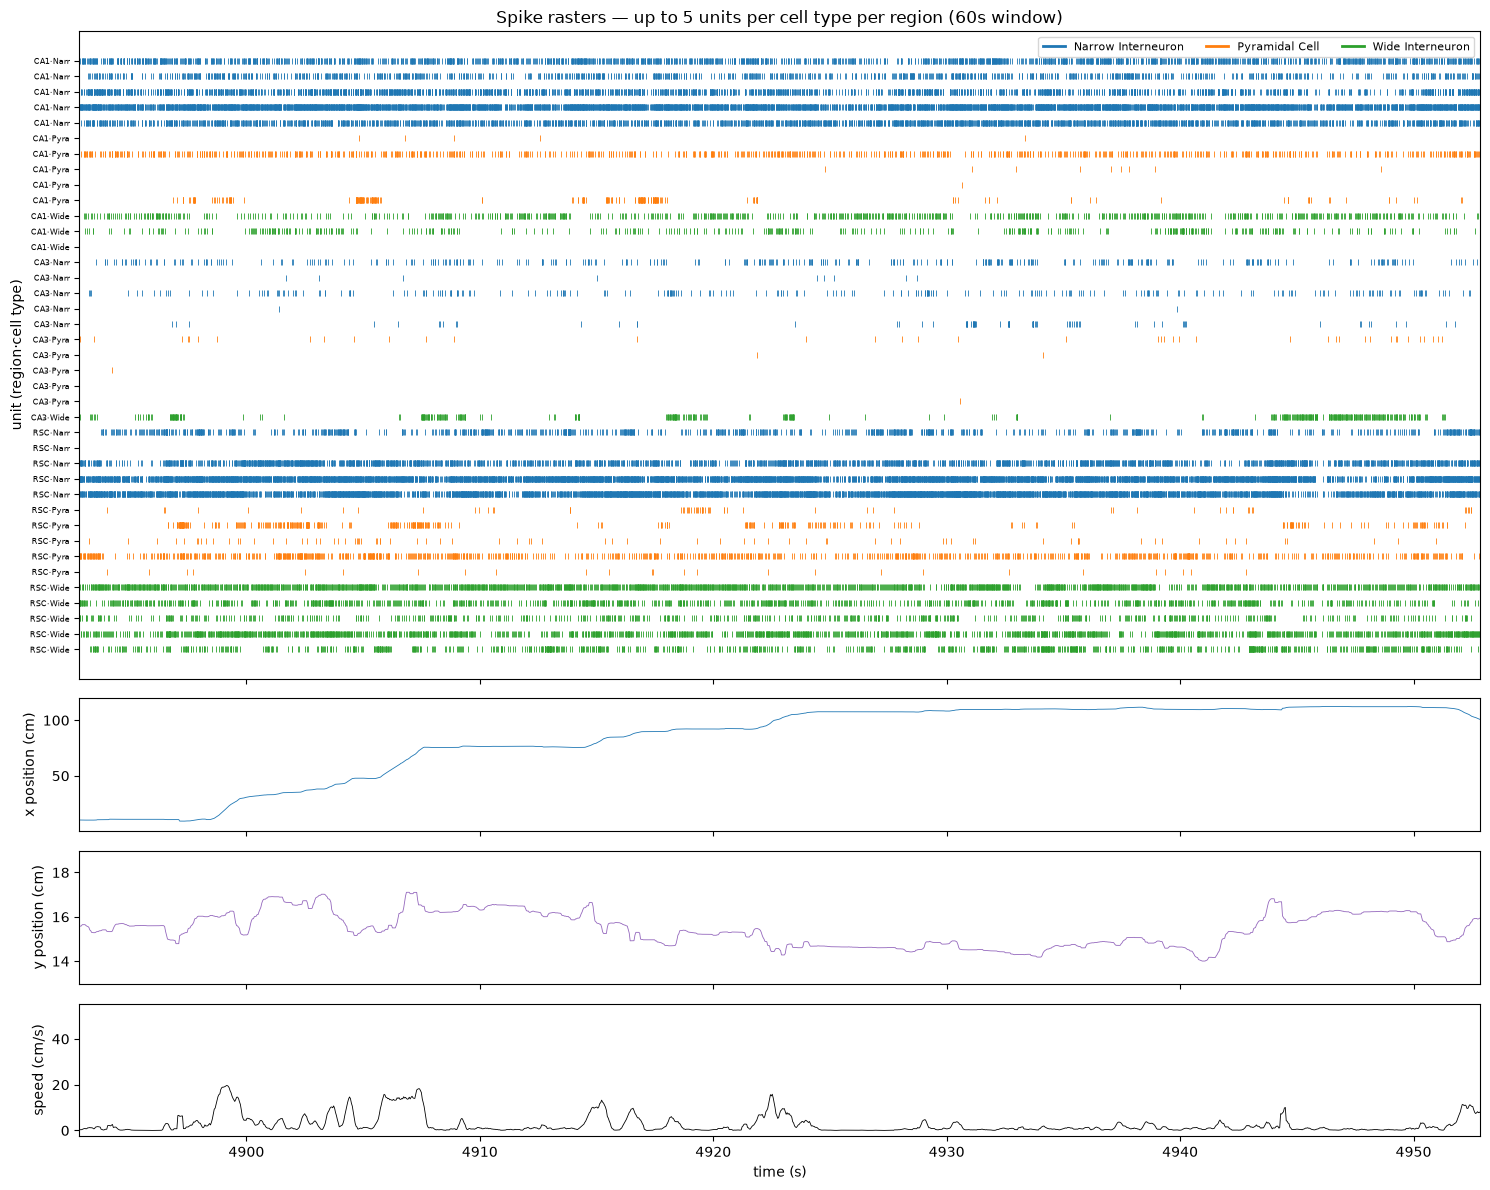

Showing 39 units | window 4893–4953 s


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
import pynapple as nap

# ---- reload objects from the file so the cell stands alone ----
session_nwb_path = Path("../../storage/dandi_downloads/sub-M01/"
                        "sub-M01_ses-20240313T100000_behavior+ecephys.nwb").resolve()
session_nwb  = nap.load_file(str(session_nwb_path))
spike_group  = session_nwb["units"]        # TsGroup: 240 units, spike times + per-unit metadata
position_xy  = session_nwb["Position"]      # TsdFrame x/y, maze epoch only

n_units_per_group = 5     # neurons to show per (region, cell_type) combo
raster_window_s   = 60    # seconds to display in the raster (short window so spikes are legible)

# ---- compute running speed from position (not reliably provided in the file) ----
position_time_s = position_xy.index.values
position_x_vals = position_xy["x"].values
position_y_vals = position_xy["y"].values
# instantaneous speed = distance between consecutive samples / dt  (units: position-units / s)
dt_s = np.diff(position_time_s)
dxy = np.sqrt(np.diff(position_x_vals)**2 + np.diff(position_y_vals)**2)
speed_vals = dxy / dt_s
speed_time_s = position_time_s[1:]               # speed is defined between samples
# light smoothing over ~0.25 s to reduce sample-to-sample jitter
smooth_n = max(1, int(0.25 / np.median(dt_s)))
speed_vals_smooth = np.convolve(speed_vals, np.ones(smooth_n)/smooth_n, mode="same")

# ---- per-unit metadata arrays ----
unit_brain_regions = np.asarray(spike_group.get_info("cell_area"))   # CA1 / CA3 / RSC
unit_cell_types    = np.asarray(spike_group.get_info("cell_type"))   # Narrow/Wide Interneuron, Pyramidal Cell
unit_id_keys       = np.asarray(spike_group.index)                   # 1-based unit keys

cell_type_names  = sorted(set(unit_cell_types))
cell_type_colors = {ct: c for ct, c in zip(cell_type_names, plt.get_cmap("tab10").colors)}

# ---- pick up to n neurons per region x cell_type ----
selected_units = []   # (unit_id, brain_region, cell_type)
for brain_region in sorted(set(unit_brain_regions)):
    for cell_type in cell_type_names:
        matching_unit_ids = unit_id_keys[(unit_brain_regions == brain_region)
                                         & (unit_cell_types == cell_type)]
        for unit_id in matching_unit_ids[:n_units_per_group]:
            selected_units.append((unit_id, brain_region, cell_type))

# ---- display window: first raster_window_s of the maze epoch ----
window_start_s = position_time_s[0]
window_end_s   = window_start_s + raster_window_s

fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True,
                         gridspec_kw={"height_ratios": [len(selected_units)/8, 1, 1, 1]})

# ---- panel 0: spike raster (windowed) ----
raster_ax = axes[0]
for raster_row, (unit_id, brain_region, cell_type) in enumerate(selected_units):
    unit_spike_times = spike_group[unit_id].get(window_start_s, window_end_s)
    raster_ax.plot(unit_spike_times.index.values,
                   np.full(len(unit_spike_times), raster_row), "|",
                   color=cell_type_colors[cell_type], markersize=4, mew=0.6)
raster_ax.set_yticks(range(len(selected_units)))
raster_ax.set_yticklabels([f"{r[:4]}·{c[:4]}" for _, r, c in selected_units], fontsize=6)
raster_ax.set(ylabel="unit (region·cell type)",
              title=f"Spike rasters — up to 5 units per cell type per region "
                    f"({raster_window_s}s window)")
raster_ax.invert_yaxis()
raster_ax.legend(handles=[Line2D([0],[0], color=cell_type_colors[ct], lw=2, label=ct)
                          for ct in cell_type_names],
                 fontsize=8, loc="upper right", ncol=len(cell_type_names))

# ---- panels 1 & 2: position x and y ----
axes[1].plot(position_time_s, position_x_vals, lw=0.6, color="tab:blue")
axes[1].set(ylabel="x position (cm)")
axes[2].plot(position_time_s, position_y_vals, lw=0.6, color="tab:purple")
axes[2].set(ylabel="y position (cm)")

# ---- panel 3: computed running speed ----
axes[3].plot(speed_time_s, speed_vals_smooth, lw=0.6, color="k")
axes[3].set(ylabel="speed (cm/s)", xlabel="time (s)")

axes[0].set_xlim(window_start_s, window_end_s)   # all panels locked to the window
plt.tight_layout(); plt.show()

print(f"Showing {len(selected_units)} units | window {window_start_s:.0f}–{window_end_s:.0f} s")

Building spike matrix (50 ms bins, per-neuron z-score)...
  done in 12.9s | matrix = (223775, 240) (time_bins, units)

[K=6] fitting...


         1 -75260939.47643825             +nan
         2 -55985684.25231786 +19275255.22412039
         3 -15014096.00975921 +40971588.24255865
         4 30790369.14619894 +45804465.15595815
         5 46545529.77302086 +15755160.62682192
         6 52671566.94939003 +6126037.17636917
         7 55284294.96859680 +2612728.01920677
         8 56608324.53732268 +1324029.56872588
         9 57373298.55007773 +764974.01275505
        10 57872314.25862921 +499015.70855148
        11 58165177.39454650 +292863.13591729
        12 58234159.25736660  +68981.86282010
        13 58252854.20011559  +18694.94274899
        14 58260299.11751791   +7444.91740232
        15 58267093.45999984   +6794.34248193
        16 58290716.89858753  +23623.43858769
        17 58493859.17129958 +203142.27271205
        18 58494252.27878369    +393.10748410
        19 58494410.10025620    +157.82147251
        20 58494511.58338140    +101.48312520
        21 58494585.43748353     +73.85410213
        22 58494629.

[K=6] done in 1934.0s | iters= 61 | converged=True | loglik=58,495,038

[K=5] fitting...


         1 -75537027.19611496             +nan
         2 -60321177.80647182 +15215849.38964314
         3 -30285579.69184571 +30035598.11462611
         4 7633531.18098429 +37919110.87283000
         5 32659555.86663490 +25026024.68565061
         6 41947406.38886801 +9287850.52223311
         7 43395575.34040646 +1448168.95153844
         8 43971089.48915923 +575514.14875278
         9 45001572.94159779 +1030483.45243856
        10 45907155.63632011 +905582.69472232
        11 45974897.98636671  +67742.35004660
        12 46016648.36376106  +41750.37739435
        13 46035171.54529559  +18523.18153453
        14 46050303.67623455  +15132.13093896
        15 46059092.31040858   +8788.63417403
        16 46087147.81996088  +28055.50955229
        17 46290595.48193146 +203447.66197058
        18 46312125.78277709  +21530.30084563
        19 46326084.18664703  +13958.40386994
        20 46382628.30305503  +56544.11640801
        21 46525856.48105784 +143228.17800280
        22 46535928.1

[K=5] done in 938.2s | iters= 34 | converged=True | loglik=46,545,413

[K=4] fitting...


...

[K=4] done in 772.0s | iters= 34 | converged=True | loglik=10,531,369

[K=3] fitting...


         1 -76140033.23528288             +nan
         2 -63665254.58254923 +12474778.65273365
         3 -41332765.03653171 +22332489.54601752
         4 -10483366.02951838 +30849399.00701333
         5 14375947.52806971 +24859313.55758809
         6 19286611.75643397 +4910664.22836426
         7 22091890.16139349 +2805278.40495952
         8 23010531.38248633 +918641.22109284
         9 23152020.64644284 +141489.26395651
        10 23396521.27500694 +244500.62856410
        11 23404673.08651012   +8151.81150318
        12 23405906.33012635   +1233.24361623
        13 23406403.38864191    +497.05851556
        14 23406573.03779884    +169.64915693
        15 23406584.78047301     +11.74267417
        16 23406622.29478664     +37.51431364
        17 23406630.56094783      +8.26616118
        18 23406622.74084676      -7.82010107
Model is not converging.  Current: 23406622.74084676 is not greater than 23406630.560947828. Delta is -7.8201010674238205


[K=3] done in 327.9s | iters= 18 | converged=True | loglik=23,406,615

[K=2] fitting...


         1 -75690440.39434975             +nan
         2 -67454833.82966138 +8235606.56468837
         3 -52129133.10784306 +15325700.72181833
         4 -30848154.28298109 +21280978.82486197
         5  491414.68140060 +31339568.96438169
         6 5698071.62914912 +5206656.94774852
         7 6010402.46841671 +312330.83926759
         8 6560052.74057876 +549650.27216205
         9 7879484.40272089 +1319431.66214213
        10 8747748.29902797 +868263.89630708
        11 8748967.49413333   +1219.19510536
        12 8749054.17397892     +86.67984559
        13 8749070.67121880     +16.49723987
        14 8749075.49515631      +4.82393752
        15 8749079.77286224      +4.27770593
        16 8749083.92768284      +4.15482059
        17 8749087.92488249      +3.99719966
        18 8749091.65333144      +3.72844894
        19 8749094.98645011      +3.33311867
        20 8749097.80887867      +2.82242856
        21 8749100.04508404      +2.23620537
        22 8749101.69142882      +1.64

[K=2] done in 411.6s | iters= 33 | converged=True | loglik=8,749,105

Sweep finished in 4480.6s total

                loglik           AIC           BIC  n_params
n_states                                                    
2         8.749105e+06 -1.749628e+07 -1.748635e+07       963
3         2.340662e+07 -4.681033e+07 -4.679539e+07      1448
4         1.053137e+07 -2.105887e+07 -2.103890e+07      1935
5         4.654541e+07 -9.308598e+07 -9.306097e+07      2424
6         5.849504e+07 -1.169842e+08 -1.169542e+08      2915


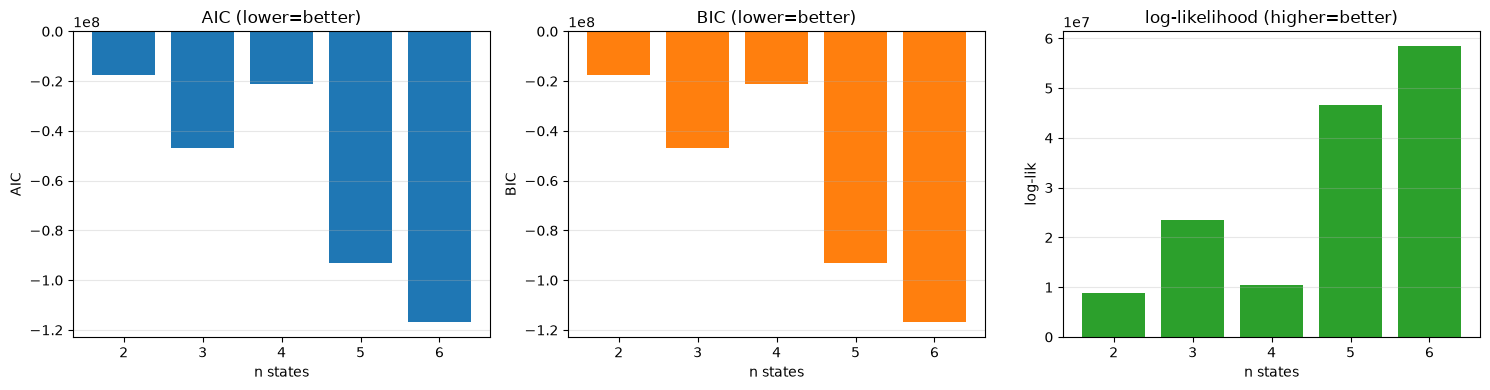

BIC picks K=6


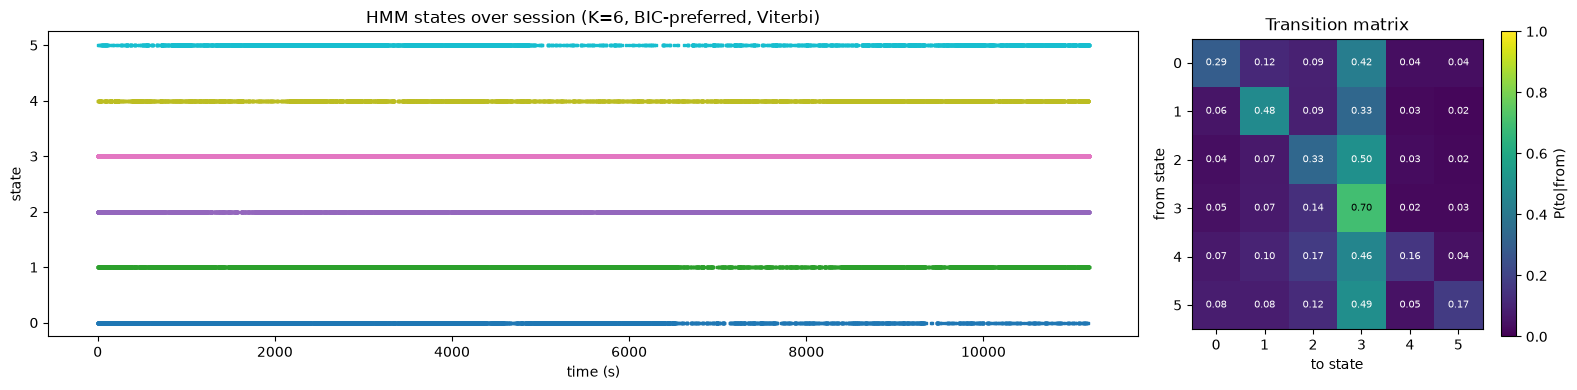

Stored models: [2, 3, 4, 5, 6]


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from hmmlearn.hmm import GaussianHMM

# ============================================================
# reusable spike-matrix builder
# ============================================================
def build_spike_matrix(spike_group, bin_size_s=0.050, zscore=True,
                       smooth_sigma_bins=None):
    """
    Bin spikes and normalize EACH neuron by its OWN activity (not the population).
    smooth_sigma_bins: leave None for HMM (it smooths via its transition matrix).
    Returns: (matrix [T bins x N units], bin_times_s [T])
    """
    binned = spike_group.count(bin_size_s)
    bin_times_s = binned.index.values
    matrix = binned.values.astype(float)

    if smooth_sigma_bins:
        from scipy.ndimage import gaussian_filter1d
        matrix = gaussian_filter1d(matrix, smooth_sigma_bins, axis=0)

    if zscore:
        unit_mean = matrix.mean(axis=0)
        unit_std  = matrix.std(axis=0)
        unit_std[unit_std == 0] = 1
        matrix = (matrix - unit_mean) / unit_std
    return matrix, bin_times_s

# ============================================================
# build emission matrix: 50 ms bins, per-neuron z-score
# ============================================================
print("Building spike matrix (50 ms bins, per-neuron z-score)...")
t_build = time.time()
spike_matrix_z, bin_times_s = build_spike_matrix(spike_group, bin_size_s=0.050, zscore=True)
print(f"  done in {time.time()-t_build:.1f}s | matrix = {spike_matrix_z.shape} "
      f"(time_bins, units)\n")

def hmm_param_count(n_states, n_features):
    return n_states*(n_states-1) + (n_states-1) + n_states*n_features + n_states*n_features

# ============================================================
# sweep 6 -> 2, printing progress + timing per fit
# ============================================================
hp_spatial_hmm_models = {}
score_rows = []
sweep_start = time.time()

for n_states in range(6, 1, -1):
    print(f"[K={n_states}] fitting...", flush=True)
    t_fit = time.time()

    hmm = GaussianHMM(n_components=n_states, covariance_type="diag",
                      n_iter=100, random_state=0,
                      verbose=True)          # prints per-iteration log-likelihood + delta
    hmm.fit(spike_matrix_z)

    fit_s = time.time() - t_fit
    loglik = hmm.score(spike_matrix_z)
    n_params = hmm_param_count(n_states, spike_matrix_z.shape[1])
    n_obs = spike_matrix_z.shape[0]
    n_iter_run = len(hmm.monitor_.history)   # how many EM iterations actually ran
    converged = hmm.monitor_.converged

    score_rows.append({
        "n_states": n_states, "loglik": loglik,
        "AIC": -2*loglik + 2*n_params,
        "BIC": -2*loglik + n_params*np.log(n_obs),
        "n_params": n_params,
    })
    hp_spatial_hmm_models[n_states] = hmm

    print(f"[K={n_states}] done in {fit_s:5.1f}s | iters={n_iter_run:3d} | "
          f"converged={converged} | loglik={loglik:,.0f}\n", flush=True)

print(f"Sweep finished in {time.time()-sweep_start:.1f}s total\n")

hmm_scores = pd.DataFrame(score_rows).set_index("n_states").sort_index()
print(hmm_scores)

# ============================================================
# scoring metrics as bar plots
# ============================================================
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].bar(hmm_scores.index, hmm_scores["AIC"], color="tab:blue")
ax[0].set(title="AIC (lower=better)", xlabel="n states", ylabel="AIC")
ax[1].bar(hmm_scores.index, hmm_scores["BIC"], color="tab:orange")
ax[1].set(title="BIC (lower=better)", xlabel="n states", ylabel="BIC")
ax[2].bar(hmm_scores.index, hmm_scores["loglik"], color="tab:green")
ax[2].set(title="log-likelihood (higher=better)", xlabel="n states", ylabel="log-lik")
for a in ax: a.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

# ============================================================
# decode BIC-preferred model
# ============================================================
best_n_states = int(hmm_scores["BIC"].idxmin())
best_hmm = hp_spatial_hmm_models[best_n_states]
state_sequence = best_hmm.predict(spike_matrix_z)
transition_matrix = best_hmm.transmat_
print(f"BIC picks K={best_n_states}")

fig, axes = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={"width_ratios": [3, 1]})
axes[0].scatter(bin_times_s, state_sequence, c=state_sequence, cmap="tab10", s=2, marker="s")
axes[0].set(xlabel="time (s)", ylabel="state", yticks=range(best_n_states),
            title=f"HMM states over session (K={best_n_states}, BIC-preferred, Viterbi)")
im = axes[1].imshow(transition_matrix, cmap="viridis", vmin=0, vmax=1)
axes[1].set(xlabel="to state", ylabel="from state",
            xticks=range(best_n_states), yticks=range(best_n_states), title="Transition matrix")
for i in range(best_n_states):
    for j in range(best_n_states):
        axes[1].text(j, i, f"{transition_matrix[i,j]:.2f}", ha="center", va="center",
                     color="w" if transition_matrix[i,j] < 0.6 else "k", fontsize=7)
fig.colorbar(im, ax=axes[1], label="P(to|from)")
plt.tight_layout(); plt.show()

print(f"Stored models: {sorted(hp_spatial_hmm_models)}")

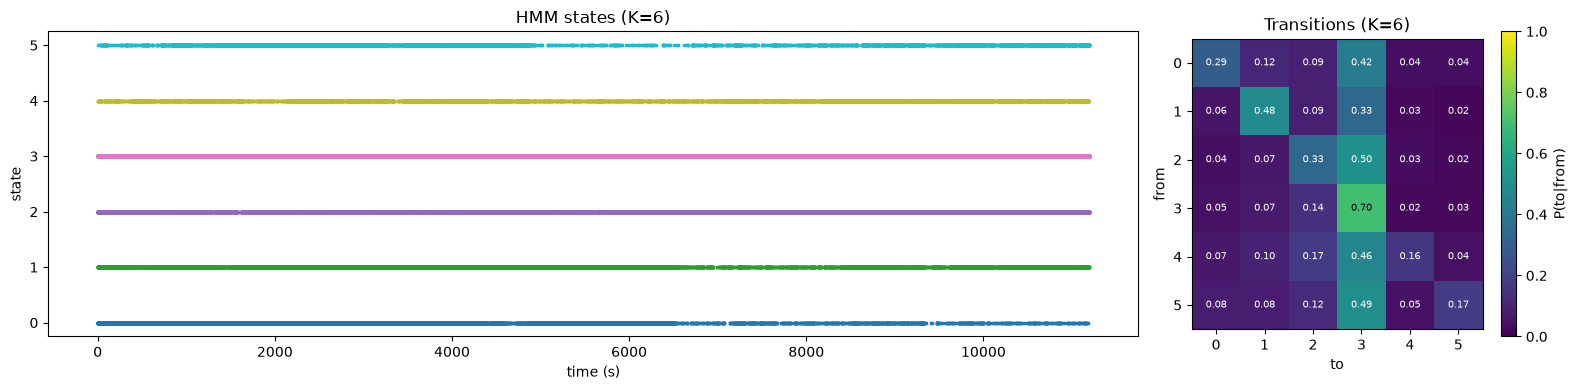

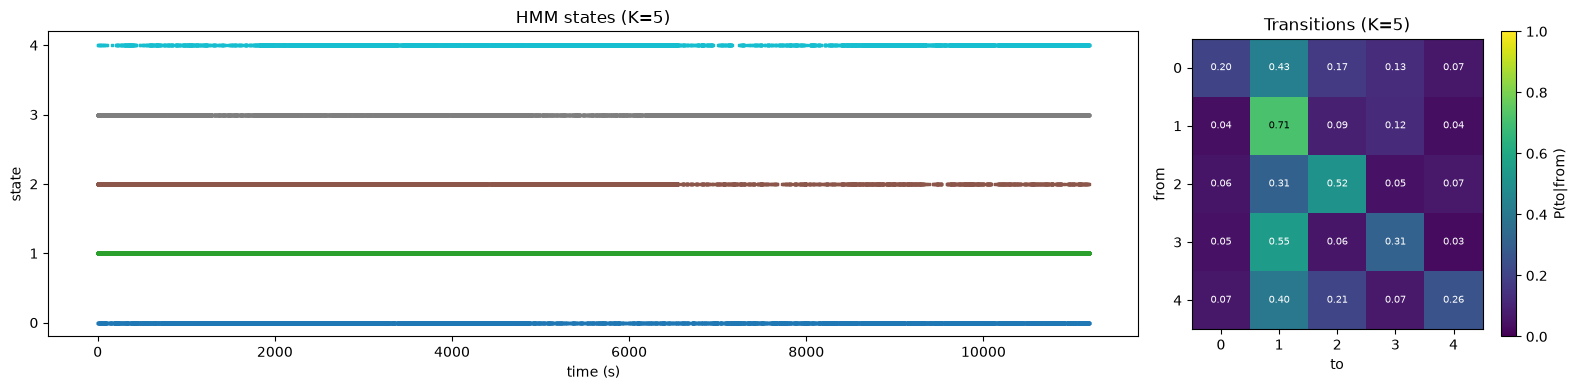

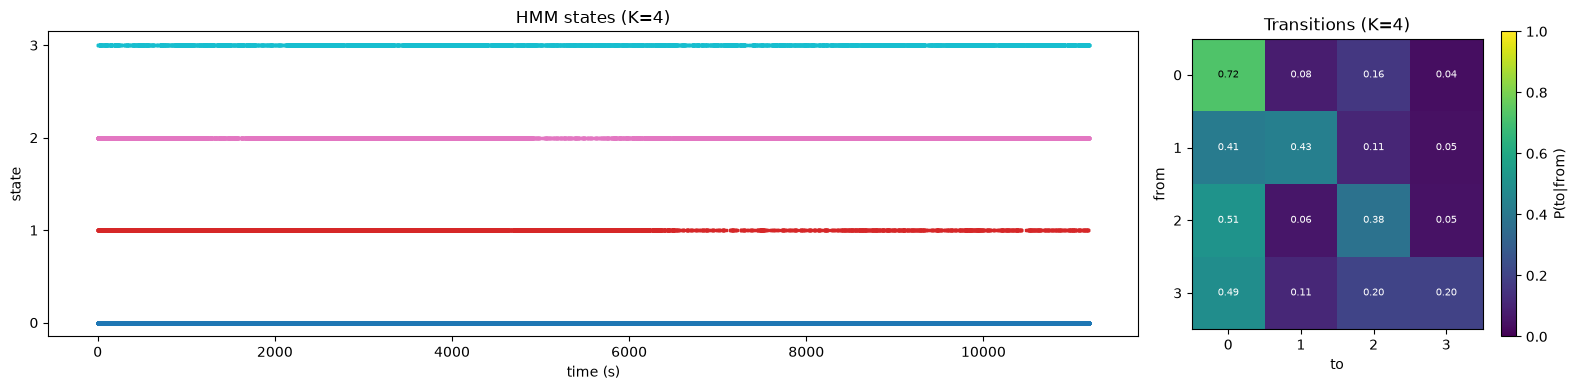

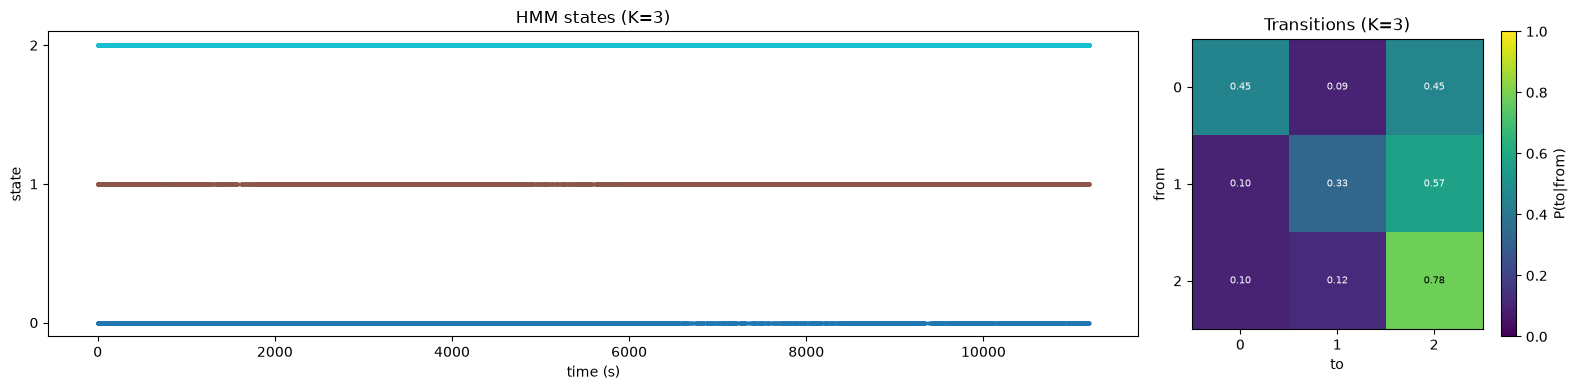

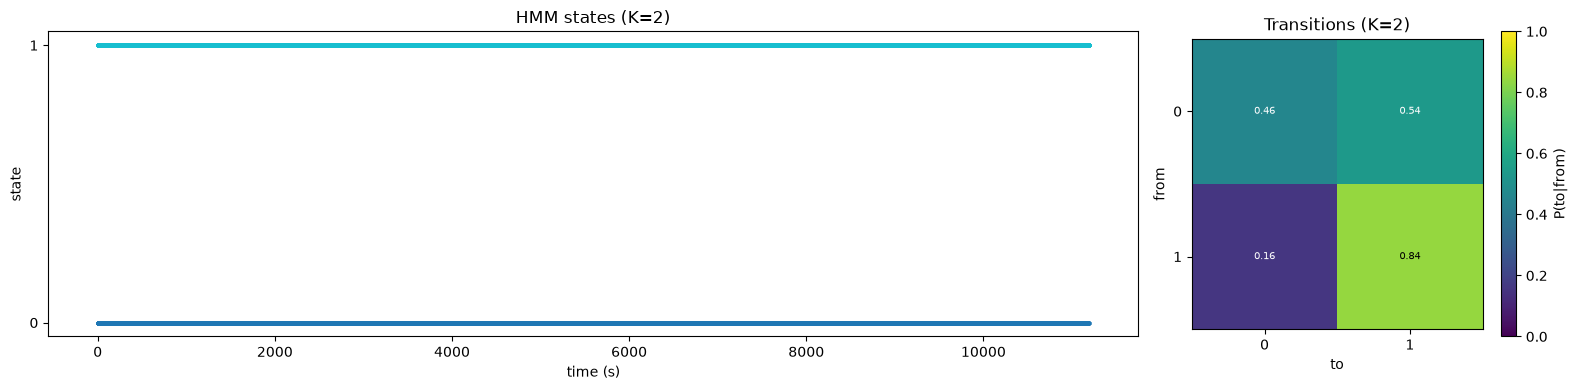

In [9]:
for n_states in sorted(hp_spatial_hmm_models, reverse=True):
    hmm = hp_spatial_hmm_models[n_states]
    seq = hmm.predict(spike_matrix_z)
    T = hmm.transmat_

    fig, axes = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={"width_ratios": [3, 1]})
    axes[0].scatter(bin_times_s, seq, c=seq, cmap="tab10", s=2, marker="s")
    axes[0].set(xlabel="time (s)", ylabel="state", yticks=range(n_states),
                title=f"HMM states (K={n_states})")
    im = axes[1].imshow(T, cmap="viridis", vmin=0, vmax=1)
    axes[1].set(xlabel="to", ylabel="from", xticks=range(n_states),
                yticks=range(n_states), title=f"Transitions (K={n_states})")
    for i in range(n_states):
        for j in range(n_states):
            axes[1].text(j, i, f"{T[i,j]:.2f}", ha="center", va="center",
                         color="w" if T[i,j] < 0.6 else "k", fontsize=7)
    fig.colorbar(im, ax=axes[1], label="P(to|from)")
    plt.tight_layout(); plt.show()

matrix: (223776, 240) | NaN/inf: False False


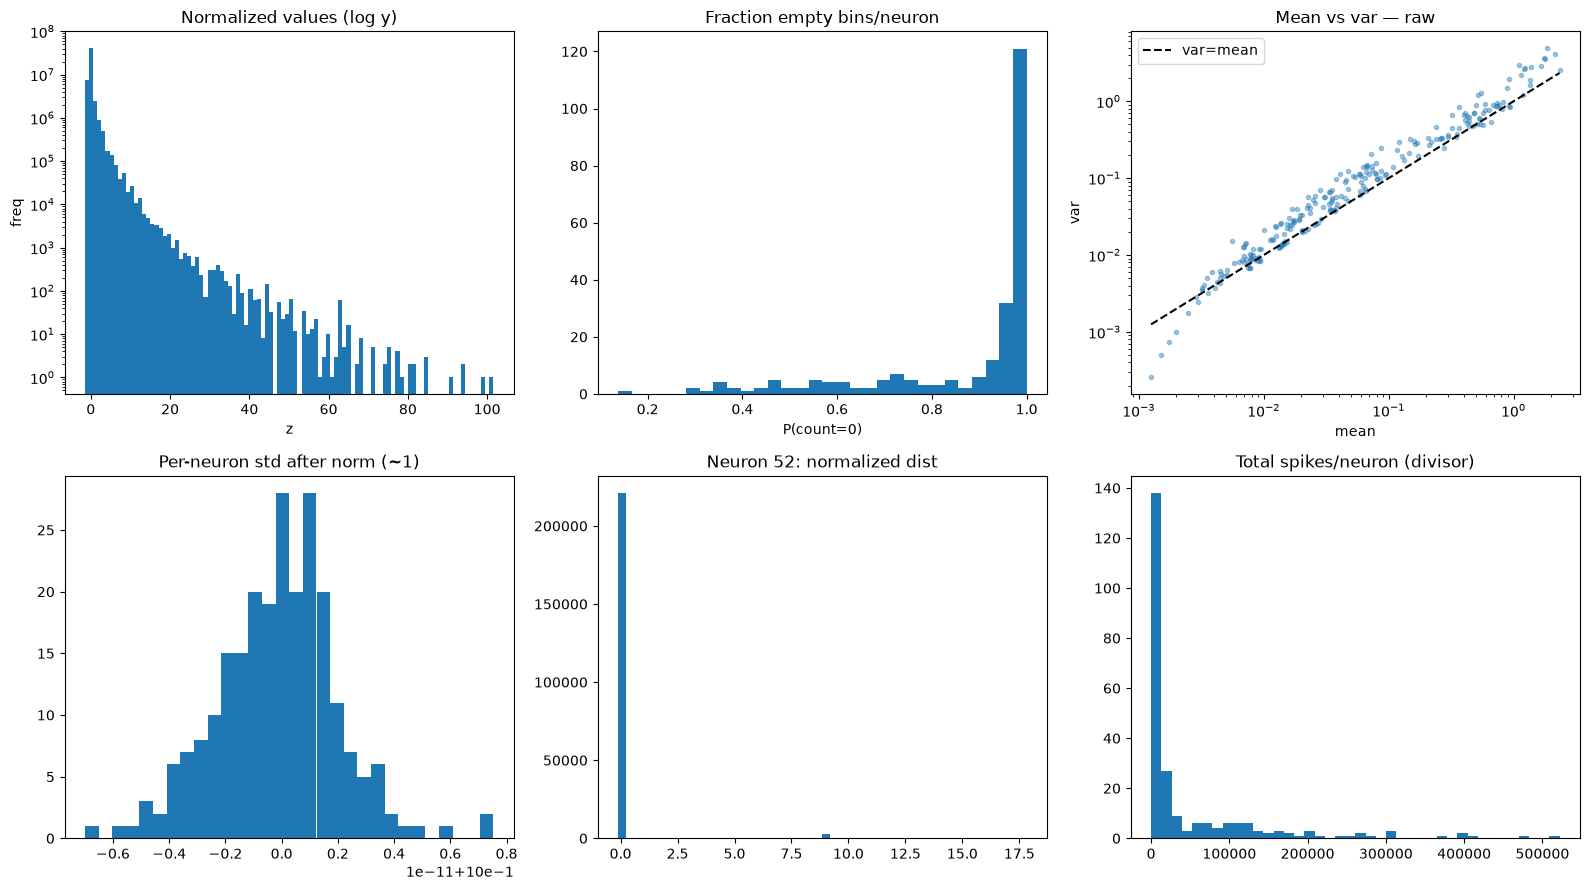

In [12]:
import numpy as np
import matplotlib.pyplot as plt

BIN = 0.050

unit_ids = np.asarray(spike_group.index)
spike_arrays = [spike_group[u].index.values for u in unit_ids]

t_start = min(s[0] for s in spike_arrays if len(s))
t_end   = max(s[-1] for s in spike_arrays if len(s))
edges = np.arange(t_start, t_end + BIN, BIN)
bin_times_s = edges[:-1]
T, N = len(edges) - 1, len(unit_ids)

# histogram does the binning (fast bin-search); one call per neuron
counts = np.stack([np.histogram(spk, bins=edges)[0] for spk in spike_arrays], axis=1).astype(float)
neuron_totals = np.array([spk.size for spk in spike_arrays], dtype=float)

# vectorized divide-by-total then z-score
neuron_totals[neuron_totals == 0] = 1
prop = counts / neuron_totals
spike_matrix_norm = (prop - prop.mean(0)) / np.where(prop.std(0) == 0, 1, prop.std(0))

print(f"matrix: {spike_matrix_norm.shape} | NaN/inf:",
      np.isnan(spike_matrix_norm).any(), np.isinf(spike_matrix_norm).any())

fig, ax = plt.subplots(2, 3, figsize=(16, 9))
ax[0,0].hist(spike_matrix_norm.ravel(), bins=100, log=True)
ax[0,0].set(title="Normalized values (log y)", xlabel="z", ylabel="freq")
frac_zero = (counts == 0).mean(0)
ax[0,1].hist(frac_zero, bins=30); ax[0,1].set(title="Fraction empty bins/neuron", xlabel="P(count=0)")
m, v = counts.mean(0), counts.var(0)
ax[0,2].loglog(m+1e-3, v+1e-6, ".", alpha=0.4)
lims=[m.min()+1e-3, m.max()]; ax[0,2].plot(lims, lims, "k--", label="var=mean")
ax[0,2].set(title="Mean vs var — raw", xlabel="mean", ylabel="var"); ax[0,2].legend()
ax[1,0].hist(spike_matrix_norm.std(0), bins=30); ax[1,0].set(title="Per-neuron std after norm (~1)")
lo = np.argsort(neuron_totals)[N//4]
ax[1,1].hist(spike_matrix_norm[:, lo], bins=50); ax[1,1].set(title=f"Neuron {lo}: normalized dist")
ax[1,2].hist(neuron_totals, bins=40); ax[1,2].set(title="Total spikes/neuron (divisor)")
plt.tight_layout(); plt.show()

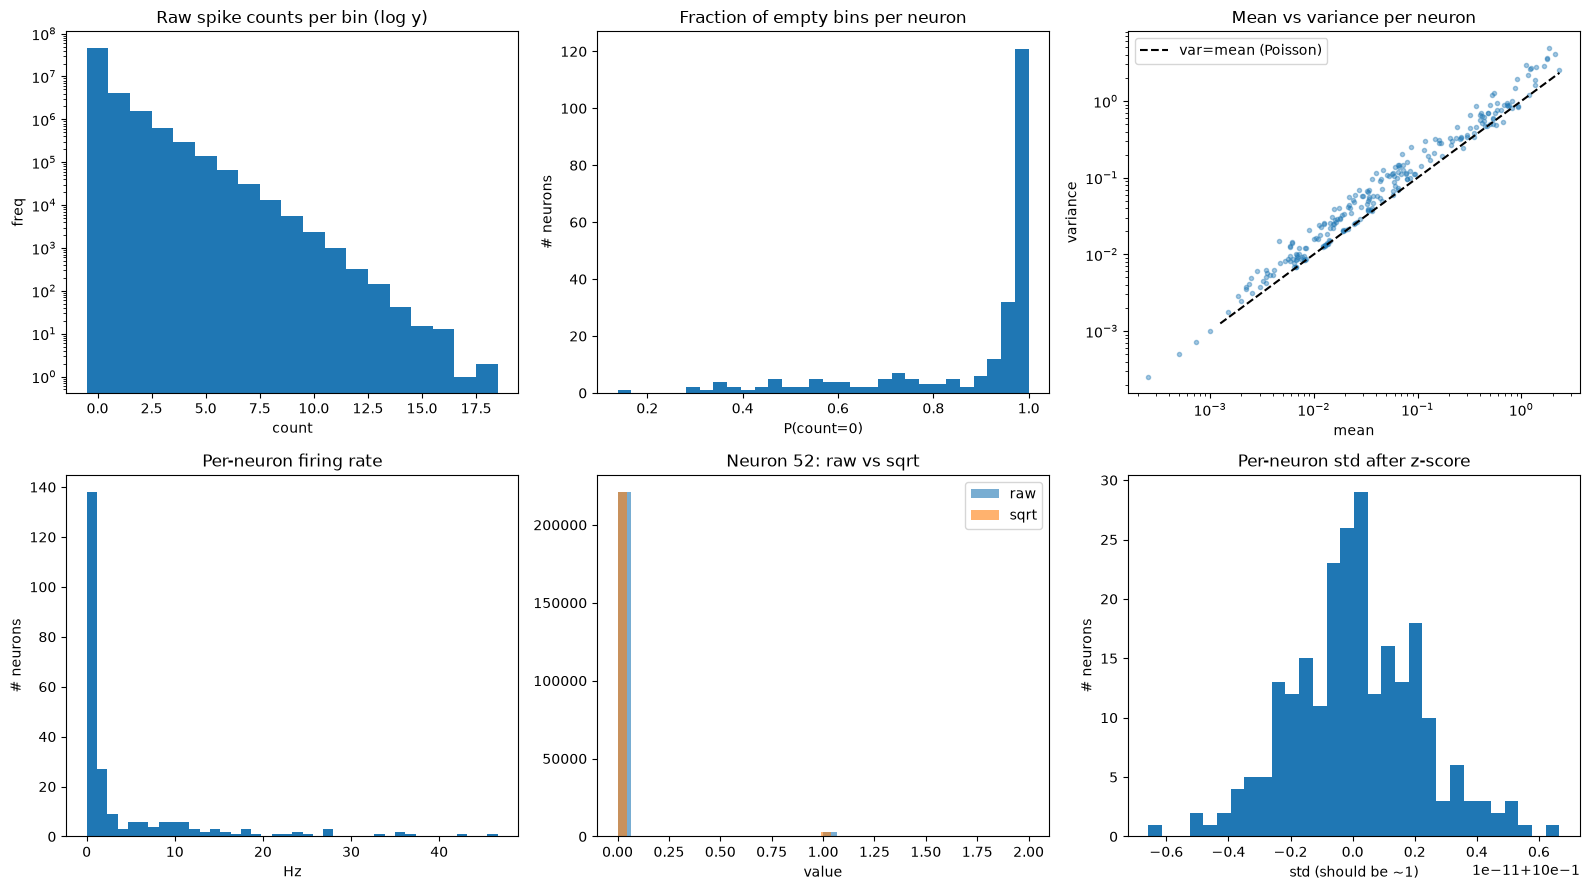

median firing rate: 0.73 Hz
median P(empty bin): 0.97
mean/var correlation: overdispersed if var >> mean


In [11]:
import numpy as np
import matplotlib.pyplot as plt

BIN = 0.050
binned = spike_group.count(BIN)          # TsdFrame [T x N], raw counts
counts = binned.values.astype(float)     # T bins x N neurons
firing_rates = counts.mean(0) / BIN      # per-neuron mean rate (Hz)

fig, ax = plt.subplots(2, 3, figsize=(16, 9))

# 1) distribution of raw counts across ALL neurons/bins — is it spiky at 0?
ax[0,0].hist(counts.ravel(), bins=np.arange(0, counts.max()+2)-0.5, log=True)
ax[0,0].set(title="Raw spike counts per bin (log y)", xlabel="count", ylabel="freq")

# 2) sparsity: fraction of bins that are ZERO, per neuron
frac_zero = (counts == 0).mean(0)
ax[0,1].hist(frac_zero, bins=30)
ax[0,1].set(title="Fraction of empty bins per neuron", xlabel="P(count=0)", ylabel="# neurons")

# 3) mean vs variance per neuron — Poisson sits on y=x; Gaussian wants flat
unit_mean = counts.mean(0); unit_var = counts.var(0)
ax[0,2].loglog(unit_mean, unit_var, ".", alpha=0.4)
lims = [unit_mean.min()+1e-3, unit_mean.max()]
ax[0,2].plot(lims, lims, "k--", label="var=mean (Poisson)")
ax[0,2].set(title="Mean vs variance per neuron", xlabel="mean", ylabel="variance"); ax[0,2].legend()

# 4) per-neuron firing-rate spread — how heterogeneous are the scales?
ax[1,0].hist(firing_rates, bins=40)
ax[1,0].set(title="Per-neuron firing rate", xlabel="Hz", ylabel="# neurons")

# 5) example single-neuron count distribution (a low-rate one) raw vs sqrt
lo = np.argsort(firing_rates)[len(firing_rates)//4]   # a lowish-rate neuron
ax[1,1].hist(counts[:, lo], bins=30, alpha=0.6, label="raw")
ax[1,1].hist(np.sqrt(counts[:, lo]), bins=30, alpha=0.6, label="sqrt")
ax[1,1].set(title=f"Neuron {lo}: raw vs sqrt", xlabel="value"); ax[1,1].legend()

# 6) does z-scoring equalize scales? std per neuron after z-score should be ~1
zc = (counts - counts.mean(0)) / np.where(counts.std(0)==0, 1, counts.std(0))
ax[1,2].hist(zc.std(0), bins=30)
ax[1,2].set(title="Per-neuron std after z-score", xlabel="std (should be ~1)", ylabel="# neurons")

plt.tight_layout(); plt.show()

print(f"median firing rate: {np.median(firing_rates):.2f} Hz")
print(f"median P(empty bin): {np.median(frac_zero):.2f}")
print(f"mean/var correlation: overdispersed if var >> mean")